In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
import time
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from skimage import io

# Data Train

In [2]:
train = '160x160/train'
train

'160x160/train'

In [3]:
import pathlib
train_dir = pathlib.Path(train)
train_dir

WindowsPath('160x160/train')

In [4]:
image_count = (
    len(list(train_dir.glob('*/*.jpg'))) +
    len(list(train_dir.glob('*/*.png'))) +
    len(list(train_dir.glob('*/*.jpeg')))
)
print(image_count)

12012


In [5]:
train_image_dict = {
    'camera': list(train_dir.glob('camera/*')),
    'crt': list(train_dir.glob('crt/*')),
    'handphone': list(train_dir.glob('handphone/*')),
    'keyboard': list(train_dir.glob('keyboard/*')),
    'kulkas': list(train_dir.glob('kulkas/*')),
    'laptop': list(train_dir.glob('laptop/*')),
    'mesin cuci': list(train_dir.glob('mesin cuci/*')),
    'microwave': list(train_dir.glob('microwave/*')),
    'mouse': list(train_dir.glob('mouse/*')),
    'printer': list(train_dir.glob('printer/*')),
    'pv panel': list(train_dir.glob('pv panel/*')),
    'smartwatch': list(train_dir.glob('smartwatch/*')),
    'monitor flat': list(train_dir.glob('monitor flat/*')),
}

In [6]:
train_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [7]:
X, y, paths = [], [], []

for train_name, images in train_image_dict.items():
    for image in images:
        img = io.imread(image)
        X.append(img)
        y.append(train_labels_dict[train_name])
        paths.append(str(image))


# Data Validation

In [8]:
val = '160x160/val'
val

'160x160/val'

In [9]:
import pathlib
val_dir = pathlib.Path(val)
val_dir

WindowsPath('160x160/val')

In [10]:
image_count = (
    len(list(val_dir.glob('*/*.jpg'))) +
    len(list(val_dir.glob('*/*.png'))) +
    len(list(val_dir.glob('*/*.jpeg')))
)
print(image_count)

2574


In [11]:
val_image_dict = {
    'camera': list(val_dir.glob('camera/*')),
    'crt': list(val_dir.glob('crt/*')),
    'handphone': list(val_dir.glob('handphone/*')),
    'keyboard': list(val_dir.glob('keyboard/*')),
    'kulkas': list(val_dir.glob('kulkas/*')),
    'laptop': list(val_dir.glob('laptop/*')),
    'mesin cuci': list(val_dir.glob('mesin cuci/*')),
    'microwave': list(val_dir.glob('microwave/*')),
    'mouse': list(val_dir.glob('mouse/*')),
    'printer': list(val_dir.glob('printer/*')),
    'pv panel': list(val_dir.glob('pv panel/*')),
    'smartwatch': list(val_dir.glob('smartwatch/*')),
    'monitor flat': list(val_dir.glob('monitor flat/*')),
}

In [12]:
val_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [13]:
X_val, y_val, paths_val = [], [], []

for val_name, images in val_image_dict.items():
    for image in images:
        img = io.imread(image)
        X_val.append(img)
        y_val.append(val_labels_dict[val_name])
        paths_val.append(str(image))


# Build Model

In [14]:
from tensorflow.keras.applications import ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape = (160,160,3)
)

for layer in base_model.layers:
    layer.trainable = False

In [15]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(13, activation='softmax')  # jumlah class
])


In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 160, 160, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 5, 5, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 13)                26637     
                                                                 
Total params: 23,614,349
Trainable params: 26,637
Non-trainable params: 23,587,712
_________________________________________________________________


In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
X = np.array(X)
y = np.array(y)
X_val = np.array(X_val)
y_val = np.array(y_val)

In [19]:
start = time.time()
history = model.fit(
    X,
    y,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=1,
    shuffle= True
)
end = time.time()

Epoch 1/15
376/376 [==============================] - 21s 56ms/step - loss: 2.0143 - accuracy: 0.3567 - val_loss: 1.9803 - val_accuracy: 0.3765
Epoch 7/15
376/376 [==============================] - 19s 51ms/step - loss: 1.9801 - accuracy: 0.3671 - val_loss: 1.9558 - val_accuracy: 0.3920
Epoch 8/15
376/376 [==============================] - 21s 56ms/step - loss: 1.9530 - accuracy: 0.3782 - val_loss: 1.9303 - val_accuracy: 0.3784
Epoch 9/15
376/376 [==============================] - 19s 52ms/step - loss: 1.9286 - accuracy: 0.3880 - val_loss: 1.9021 - val_accuracy: 0.3978
Epoch 10/15
376/376 [==============================] - 19s 50ms/step - loss: 1.9076 - accuracy: 0.3904 - val_loss: 1.8759 - val_accuracy: 0.4033
Epoch 11/15
376/376 [==============================] - 19s 51ms/step - loss: 1.8868 - accuracy: 0.3984 - val_loss: 1.8691 - val_accuracy: 0.4165
Epoch 12/15
376/376 [==============================] - 19s 50ms/step - loss: 1.8687 - accuracy: 0.4063 - val_loss: 1.8460 - val_accura

In [20]:
waktu_training = end-start
minutes = int(waktu_training // 60)  # Bagian menit
seconds = waktu_training % 60
print(f"{waktu_training} detik = {minutes} menit {seconds:.2f} detik")

312.9006350040436 detik = 5 menit 12.90 detik


# Grafik

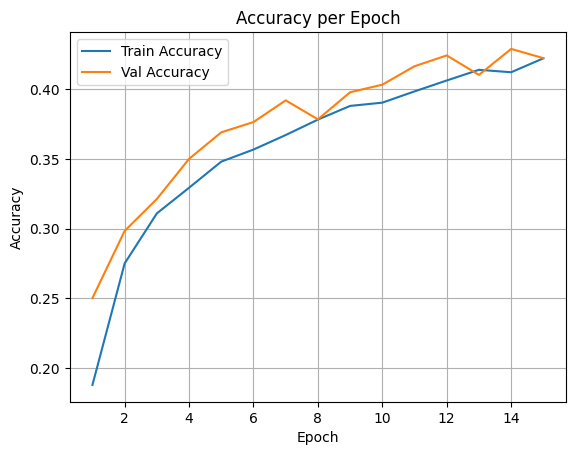

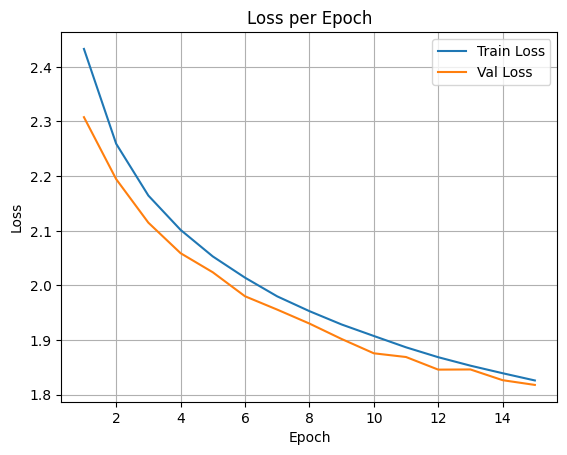

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

# Akurasi
plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Test

In [22]:
test = '160x160/test'
test

'160x160/test'

In [23]:
import pathlib
test_dir = pathlib.Path(test)
test_dir

WindowsPath('160x160/test')

In [24]:
image_count = (
    len(list(test_dir.glob('*/*.jpg'))) +
    len(list(test_dir.glob('*/*.png'))) +
    len(list(test_dir.glob('*/*.jpeg')))
)
print(image_count)

2574


In [25]:
test_image_dict = {
    'camera': list(test_dir.glob('camera/*')),
    'crt': list(test_dir.glob('crt/*')),
    'handphone': list(test_dir.glob('handphone/*')),
    'keyboard': list(test_dir.glob('keyboard/*')),
    'kulkas': list(test_dir.glob('kulkas/*')),
    'laptop': list(test_dir.glob('laptop/*')),
    'mesin cuci': list(test_dir.glob('mesin cuci/*')),
    'microwave': list(test_dir.glob('microwave/*')),
    'mouse': list(test_dir.glob('mouse/*')),
    'printer': list(test_dir.glob('printer/*')),
    'pv panel': list(test_dir.glob('pv panel/*')),
    'smartwatch': list(test_dir.glob('smartwatch/*')),
    'monitor flat': list(test_dir.glob('monitor flat/*')),
}

In [26]:
test_labels_dict = {
    'camera': 0,
    'crt': 1,
    'handphone': 2,
    'keyboard': 3,
    'kulkas': 4,
    'laptop': 5,
    'mesin cuci': 6,
    'microwave': 7,
    'mouse': 8,
    'printer': 9,
    'pv panel': 10,
    'smartwatch':11,
    'monitor flat':12
}

In [27]:
X_test, y_test, paths_test = [], [], []

for test_name, images in test_image_dict.items():
    for image in images:
        img = io.imread(image)
        X_test.append(img)
        y_test.append(test_labels_dict[test_name])
        paths_test.append(str(image))


In [28]:
X_test = np.array(X_test)
y_test = np.array(y_test)

In [29]:
model.evaluate(X_test, y_test)

81/81 [==============================] - 4s 41ms/step - loss: 1.8286 - accuracy: 0.4285


[1.8285926580429077, 0.4285159409046173]